# CS4403 Data Mining Project — Darknet Traffic Mining & Classification (CIC-Darknet2020)

## Project overview
This project uses **network flow data** to explore whether different types of internet traffic (especially **privacy-enhancing traffic like Tor and VPN**) show measurable statistical patterns.  
Each row in the dataset represents a **single network flow** (a summarized communication session), and each column contains a numeric feature describing that flow (e.g., packet counts, packet length statistics, timing/inter-arrival statistics, and active/idle behavior).

## Dataset
- **Name / Source:** CIC-Darknet2020 (Canadian Institute for Cybersecurity, University of New Brunswick)
- **Local file used in this notebook:** `Darknet.CSV`
- **Scale:** ~140k+ flow records and ~80+ features (exact counts printed after loading)
- **Labels (targets):**
  - `Label` → **Traffic type** (e.g., Tor / VPN / NonVPN / Non-Tor depending on the dataset version)
  - `Label.1` → **Application category** (e.g., Browsing, Chat, Audio-Streaming, File-Transfer, etc.)

## Project goals
### Goal 1 — Supervised learning (classification)
Build and compare machine learning models that can predict the **traffic type** (`Label`) from flow features.  
We evaluate models using metrics such as **accuracy, precision, recall, F1-score**, and a **confusion matrix** to understand where the model performs well or struggles.

### Goal 2 — Unsupervised learning (pattern discovery)
Explore whether flows naturally form groups using clustering (e.g., K-means / DBSCAN).  
This helps answer: *Do different traffic types form distinct clusters based only on their behavior features?*

### Goal 3 — Explainability and reliability
Because very high accuracy can sometimes happen due to shortcuts (e.g., hidden leakage, duplicates, or latent factors), we include checks to:
- test **overfitting risk** (train vs test gap, cross-validation)
- test for **data leakage / shortcuts** (dropping identifier-like columns)
- investigate **latent factors** (relationships between `Label` and `Label.1`, duplicates, and group-based splits if possible)
- explain what the model is using via **feature importance**

## What this notebook contains
1. Load dataset and summarize size/labels (required for reports)
2. Data cleaning and preprocessing
3. Exploratory Data Analysis (EDA)
4. Baseline supervised models + evaluation
5. Clustering exploration (optional section)
6. Robustness checks (overfitting / leakage / latent factors)
7. Feature importance + interpretation

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
)


from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    classification_report
)

pd.set_option('display.max_columns', 100)
%matplotlib inline

## 1) Setup + dataset download


In [41]:
import gdown

# Paste your Google Drive share link here (file link)
GDRIVE_URL = "https://drive.google.com/file/d/1dCmJ3NhCZ7QP_w3t5mdS04Lqg8n4MP5I/view?usp=drive_link"

# Download (fuzzy=True handles common Drive link formats)
# Output filename can be whatever you want
if GDRIVE_URL:
    gdown.download(GDRIVE_URL, output="Darknet.CSV", quiet=False, fuzzy=True)

DATA_PATH = "Darknet.CSV"
print("DATA_PATH =", DATA_PATH)

Downloading...
From: https://drive.google.com/uc?id=1dCmJ3NhCZ7QP_w3t5mdS04Lqg8n4MP5I
To: c:\Users\jaspi\Desktop\Winter 2026\CS4403\Project\CS4403-Project-main\CS4403-Project-main\Code\Darknet.CSV
100%|██████████| 66.3M/66.3M [00:00<00:00, 74.6MB/s]

DATA_PATH = Darknet.CSV


## 2) Load dataset + quick summary

Why: Your report needs the **format**, **#instances**, **#features**, and label breakdown.


In [42]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")], errors="ignore")

print("Format: CSV")
print("Rows, Columns =", df.shape)
df.head(3)

Format: CSV
Rows, Columns = (141531, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label.1
0,10.152.152.11-216.58.220.99-57158-443-6,10.152.152.11,57158,216.58.220.99,443,6,24/07/2015 04:09:48 PM,229,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,8733.624454,229.0,0.0,229,229,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,4366.812227,4366.812227,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1892,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING
1,10.152.152.11-216.58.220.99-57159-443-6,10.152.152.11,57159,216.58.220.99,443,6,24/07/2015 04:09:48 PM,407,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,4914.004914,407.0,0.0,407,407,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2457.002457,2457.002457,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,1987,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING
2,10.152.152.11-216.58.220.99-57160-443-6,10.152.152.11,57160,216.58.220.99,443,6,24/07/2015 04:09:48 PM,431,1,1,0,0,0,0,0.0,0.0,0,0,0.0,0.0,0.0,4640.371230,431.0,0.0,431,431,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2320.185615,2320.185615,0,0,0,0.0,0.0,2,0,0,0,2,0,0,0,1,0.0,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,2049,1047,0,20,0,0,0,0,0.0,0.0,0.0,0.0,Non-Tor,AUDIO-STREAMING


In [43]:
print("Columns:")
print(df.columns.tolist())

print("\nDtypes (count):")
print(df.dtypes.value_counts())

print("\nMissing values (total):", int(df.isna().sum().sum()))

Columns:
['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Fla

In [44]:
print(df['Label'].value_counts())

print("\n-----------------\n")

print(df['Label.1'].value_counts())

Label
Non-Tor        93356
NonVPN         23863
VPN            22919
Tor             1392
5494.505495        1
Name: count, dtype: int64

-----------------

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    16580
Chat               11478
File-Transfer      11098
Video-Streaming     9486
Email               6145
VOIP                3566
AUDIO-STREAMING     1484
Video-streaming      281
File-transfer         84
0                      1
Name: count, dtype: int64


## 3) Label cleaning (fix known bad rows)

**Why:** The raw dataset contains a small number of corrupted/invalid label rows (e.g., a numeric value in `Label` or `0` in `Label.1`).  
Cleaning labels ensures model results are based on valid ground truth and are reproducible.

In [45]:
# Keep only valid traffic labels (removes the corrupted '5494.505495' row)
valid_labels = ["Non-Tor", "NonVPN", "VPN", "Tor"]
df = df[df["Label"].isin(valid_labels)].copy()

# Standardize Label.1 naming
df["Label.1"] = df["Label.1"].replace({
    "AUDIO-STREAMING": "Audio-Streaming",
    "Video-streaming": "Video-Streaming",
    "File-transfer": "File-Transfer",
})

# Remove invalid application label rows
df = df[df["Label.1"].notna()].copy()
df = df[df["Label.1"].astype(str).str.strip() != "0"].copy()

print(df["Label"].value_counts())
print("\n---\n")
print(df["Label.1"].value_counts())

Label
Non-Tor    93356
NonVPN     23863
VPN        22919
Tor         1392
Name: count, dtype: int64

---

Label.1
P2P                48520
Browsing           32808
Audio-Streaming    18064
Chat               11478
File-Transfer      11182
Video-Streaming     9767
Email               6145
VOIP                3566
Name: count, dtype: int64


## 4) EDA: check for latent factors (confounders)

**Why:** High accuracy can happen if another factor strongly correlates with the label.  
Here we check whether `Label` (traffic type) is strongly tied to `Label.1` (application type).  
If some applications appear mostly under one traffic type, the model may learn application signatures indirectly.

In [46]:
ct = pd.crosstab(df["Label"], df["Label.1"])
ct_norm = pd.crosstab(df["Label"], df["Label.1"], normalize="index")

print("Counts:\n", ct)
print("\nRow-normalized (within each Label):\n", ct_norm.round(3))

Counts:
 Label.1  Audio-Streaming  Browsing  Chat  Email  File-Transfer    P2P  VOIP  \
Label                                                                         
Non-Tor             1484     32545   413    492           6740  48300     0   
NonVPN              3296         0  6524   5071           1832      0  2101   
Tor                  224       263    65     13            107    220   298   
VPN                13060         0  4476    569           2503      0  1167   

Label.1  Video-Streaming  
Label                     
Non-Tor             3382  
NonVPN              5039  
Tor                  202  
VPN                 1144  

Row-normalized (within each Label):
 Label.1  Audio-Streaming  Browsing   Chat  Email  File-Transfer    P2P   VOIP  \
Label                                                                           
Non-Tor            0.016     0.349  0.004  0.005          0.072  0.517  0.000   
NonVPN             0.138     0.000  0.273  0.213          0.077  0.000  0

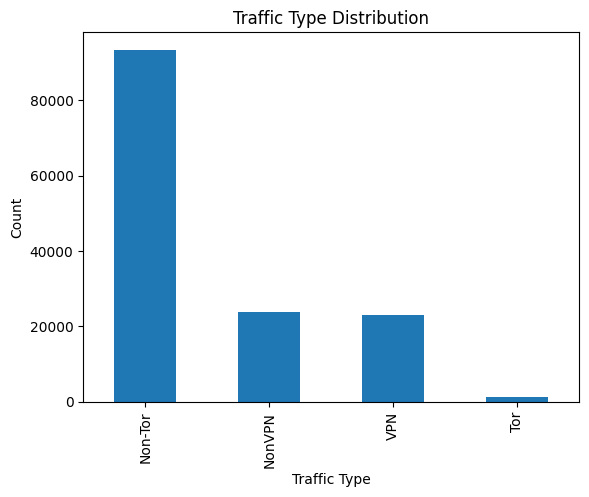

In [47]:
df['Label'].value_counts().plot(kind='bar')

plt.title('Traffic Type Distribution')
plt.xlabel('Traffic Type')
plt.ylabel('Count')

plt.show()

## 5) Supervised model (Random Forest baseline)

**Why Random Forest:** It performs well on tabular numeric data and can capture non-linear patterns.  
**Important:** We drop identifiers and potential shortcuts (IP/ports/protocol/timestamps) so the model learns traffic *behavior*, not metadata.  
We also report macro-F1 and balanced accuracy because the classes are imbalanced.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score

drop_cols = [
    "Flow ID", "Src IP", "Dst IP", "Timestamp",
    "Src Port", "Dst Port", "Protocol",   # <- important
    "Label", "Label.1"
]

X = df.drop(columns=drop_cols, errors="ignore").copy()
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

le = LabelEncoder()
y = le.fit_transform(df["Label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

model.fit(X_train, y_train)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, pred_train))
print("Test accuracy :", accuracy_score(y_test, pred_test))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, pred_test))
print("Test macro F1:", f1_score(y_test, pred_test, average="macro"))

print("\nClassification report:\n")
print(classification_report(y_test, pred_test, target_names=le.classes_))

Train accuracy: 0.9965025083021267
Test accuracy : 0.9810640853529287
Test balanced accuracy: 0.9461602363942392
Test macro F1: 0.9554091716291293

Classification report:

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.95      0.95      0.95      4773
         Tor       0.97      0.89      0.93       278
         VPN       0.95      0.95      0.95      4584

    accuracy                           0.98     28306
   macro avg       0.97      0.95      0.96     28306
weighted avg       0.98      0.98      0.98     28306



### 5.1 Random Forest hyperparameter tuning

To improve the baseline model, we tune a small set of important Random Forest parameters.  
We keep the search compact so it runs in reasonable time in Colab while still testing whether performance can be improved.

In [72]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [None, 20, 30],
    "rf__min_samples_split": [2, 5],
    "rf__class_weight": [None, "balanced", "balanced_subsample"]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
pred_best = best_model.predict(X_test)

print("Best parameters:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)
print("Tuned RF test accuracy:", accuracy_score(y_test, pred_best))
print("Tuned RF balanced accuracy:", balanced_accuracy_score(y_test, pred_best))
print("Tuned RF macro-F1:", f1_score(y_test, pred_best, average="macro"))

print("\nClassification report (Tuned RF):\n")
print(classification_report(y_test, pred_best, target_names=le.classes_))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'rf__class_weight': None, 'rf__max_depth': 20, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
Best CV macro-F1: 0.9605203139901448
Tuned RF test accuracy: 0.9843496078569914
Tuned RF balanced accuracy: 0.9559698068439121
Tuned RF macro-F1: 0.9655757872868369

Classification report (Tuned RF):

              precision    recall  f1-score   support

     Non-Tor       1.00      1.00      1.00     18671
      NonVPN       0.95      0.96      0.96      4773
         Tor       0.99      0.91      0.95       278
         VPN       0.96      0.95      0.96      4584

    accuracy                           0.98     28306
   macro avg       0.98      0.96      0.97     28306
weighted avg       0.98      0.98      0.98     28306



**Interpretation (Tuned Random Forest):**  
Hyperparameter tuning checks whether the baseline model can be improved through better parameter choices.  
We compare the tuned model with the original Random Forest using macro-F1, balanced accuracy, and the class-wise report.  
If the gain is small, that suggests the baseline was already strong; if the gain is noticeable, we report the tuned model as our best supervised result.

### 5.2 Feature importance (Random Forest)

Random Forest can estimate which features contributed most to the predictions.  
This helps us understand which traffic characteristics matter most for distinguishing traffic classes.

In [ ]:
# Use the tuned model if available; otherwise use the original baseline model
rf_for_importance = best_model.named_steps["rf"] if "best_model" in globals() else model.named_steps["rf"]

feature_names = X.columns
importances = rf_for_importance.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(feat_imp.head(15))

plt.figure(figsize=(10, 6))
plt.barh(feat_imp["Feature"].head(15)[::-1], feat_imp["Importance"].head(15)[::-1])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

**Interpretation (Feature importance):**  
The top-ranked features indicate which flow-level measurements the Random Forest relied on most.  
This makes the model more interpretable and helps connect the classification results back to network traffic behavior rather than only reporting accuracy numbers.

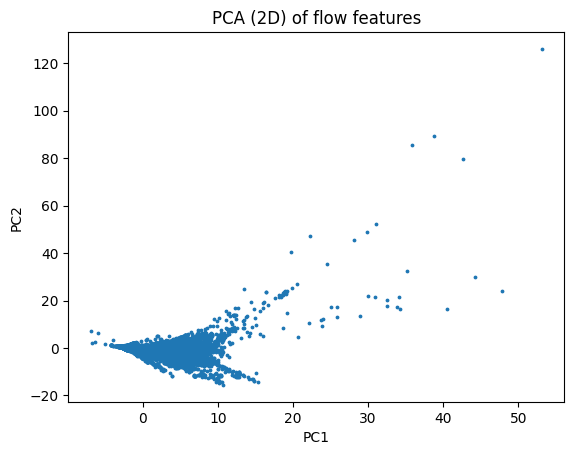

In [49]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_s = X.sample(n=min(20000, len(X)), random_state=42)  # sample for speed
X_scaled = StandardScaler().fit_transform(X_s.fillna(X_s.median(numeric_only=True)))

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=3)
plt.title("PCA (2D) of flow features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 6) Robustness checks (overfitting + leakage risk)

**Why:** Very high accuracy can be real, but it can also happen due to evaluation shortcuts
(e.g., duplicates across train/test, latent factors, or overfitting).
These checks help validate that our results generalize and are trustworthy.

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# macro-F1 is important because classes can be imbalanced
scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro", n_jobs=-1)

print("5-fold CV macro-F1 scores:", scores)
print("Mean macro-F1:", scores.mean())
print("Std macro-F1:", scores.std())

5-fold CV macro-F1 scores: [0.9550351  0.95214518 0.95925617 0.95669524 0.9592473 ]
Mean macro-F1: 0.9564757973997604
Std macro-F1: 0.002694055855245628


**Interpretation (Cross-Validation):**  
We ran 5-fold stratified cross-validation using **macro-F1** (macro-averaging treats each class equally, which matters for imbalanced labels).  
The scores are consistent across folds (mean ≈ 0.9565, std ≈ 0.0027).  
This indicates the model generalizes well across different splits and reduces concern that our high performance is due to overfitting to one train/test split.

In [51]:
from sklearn.metrics import accuracy_score
rng = np.random.default_rng(42)

y_shuffled = rng.permutation(y)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X, y_shuffled, test_size=0.2, random_state=42, stratify=y_shuffled
)

model.fit(X_train_s, y_train_s)
pred_shuffle = model.predict(X_test_s)

print("Shuffled-label TEST accuracy:", accuracy_score(y_test_s, pred_shuffle))

Shuffled-label TEST accuracy: 0.5252243340634495


**Interpretation (Label-Shuffle Sanity Test):**  
To test for leakage or accidental shortcuts, we randomly shuffled the target labels and retrained the model.  
Performance dropped to ~0.525 accuracy, which is near baseline and far below the real model performance.  
This supports that the model’s high accuracy is driven by real structure in the features, not by data leakage or evaluation artifacts.

### Baseline check (Majority-class / “dumb” model)

**Why:** To interpret the shuffled-label result, we need a baseline.  
A very simple model that always predicts the most common class tells us what “no real learning” looks like.  
If our shuffled-label accuracy is close to this baseline, that supports that the real high accuracy is due to actual structure, not leakage.

In [52]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
import numpy as np

# Majority-class baseline (always predicts the most frequent class in training data)
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Majority-class baseline accuracy:", accuracy_score(y_test, pred_dummy))
print("Majority-class baseline balanced accuracy:", balanced_accuracy_score(y_test, pred_dummy))
print("Majority-class baseline macro-F1:", f1_score(y_test, pred_dummy, average="macro"))

# Helpful context: what is the most common class in the test split?
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest split class distribution (encoded):", dict(zip(unique, counts)))

Majority-class baseline accuracy: 0.6596128029393061
Majority-class baseline balanced accuracy: 0.25
Majority-class baseline macro-F1: 0.19872490793366968

Test split class distribution (encoded): {np.int64(0): np.int64(18671), np.int64(1): np.int64(4773), np.int64(2): np.int64(278), np.int64(3): np.int64(4584)}


### Duplicate-row check (possible evaluation inflation)

**Why:** If many rows have identical feature values, random train/test splits can place duplicates in both sets.  
That can make results look overly strong.  
We measure duplicate rate and then re-evaluate after removing duplicate feature rows.

In [53]:
# Duplicate feature rows based on the model input features (X)
dup_count = pd.DataFrame(X).duplicated().sum()
print("Duplicate feature rows:", dup_count)
print("Duplicate rate:", dup_count / len(X))

Duplicate feature rows: 41476
Duplicate rate: 0.2930544760828093


In [54]:
# Build a deduplicated dataset (keep first occurrence)
X_df = pd.DataFrame(X).copy()
X_df["y"] = y

X_dedup = X_df.drop_duplicates(subset=X_df.columns.difference(["y"])).copy()

y_d = X_dedup["y"].to_numpy()
X_d = X_dedup.drop(columns=["y"])

scores_d = cross_val_score(model, X_d, y_d, cv=cv, scoring="f1_macro", n_jobs=-1)

print("Dedup rows:", len(X_dedup))
print("Dedup 5-fold CV macro-F1:", scores_d)
print("Dedup mean macro-F1:", scores_d.mean())
print("Dedup std:", scores_d.std())

Dedup rows: 100054
Dedup 5-fold CV macro-F1: [0.95337664 0.95795044 0.95743124 0.95729712 0.95203868]
Dedup mean macro-F1: 0.955618824598085
Dedup std: 0.002424161369907356


**Interpretation (Duplicates):**  
About 29% of rows had identical feature values, which could inflate results if duplicates appear in both train and test sets.  
To test this, we removed duplicate feature rows and re-ran 5-fold CV.  
Macro-F1 remained essentially unchanged (~0.956 → ~0.956), suggesting our strong performance is not primarily caused by duplicate leakage.

In [55]:
print("Src IP in df?", "Src IP" in df.columns)
print("Dst IP in df?", "Dst IP" in df.columns)
print("Timestamp in df?", "Timestamp" in df.columns)

Src IP in df? True
Dst IP in df? True
Timestamp in df? True


### Group split (latent factor check)

**Why:** A normal random split can overestimate performance if traffic from the same source (or capture environment) appears in both training and test sets.  
We perform a **group-based split** using `Src IP` so the model is tested on source IPs it has never seen during training.  
If performance drops a lot, it suggests a latent factor (source/capture environment) influences the model.

In [56]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import balanced_accuracy_score, f1_score, accuracy_score

# groups = source IP (latent factor / environment)
groups = df["Src IP"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_g, X_test_g = X.iloc[train_idx], X.iloc[test_idx]
y_train_g, y_test_g = y[train_idx], y[test_idx]

model.fit(X_train_g, y_train_g)
pred_g = model.predict(X_test_g)

print("Group-split TEST accuracy:", accuracy_score(y_test_g, pred_g))
print("Group-split balanced accuracy:", balanced_accuracy_score(y_test_g, pred_g))
print("Group-split macro-F1:", f1_score(y_test_g, pred_g, average="macro"))

Group-split TEST accuracy: 0.6295493636050912
Group-split balanced accuracy: 0.6071114988930456
Group-split macro-F1: 0.5461403405903011


**Interpretation (Group split by Src IP):**  
When we force the train/test split to use **different source IPs**, performance drops (macro-F1 ≈ 0.55 vs ≈ 0.96 under random CV).  
This indicates a **latent factor**: traffic patterns can be partially source/environment dependent.  
A random split can therefore overestimate generalization because flows from the same source may appear in both training and test sets.  
We report both results: (1) random split as an optimistic upper bound, and (2) group split as a stronger generalization test.

### Control test: evaluate within each application category (`Label.1`)

**Why:** If application type strongly correlates with traffic type, a model can indirectly learn application signatures.  
To control for this, we evaluate traffic-type classification **within each application category** separately.  
This helps isolate whether the model can still separate Tor/VPN/Non… when the application category is held constant.

In [57]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

rows = []
for app, sub in df.groupby("Label.1"):
    # skip tiny groups
    if len(sub) < 1000:
        continue
    if sub["Label"].nunique() < 2:
        continue

    # build X/y the same way as main task (drop shortcuts)
    X_sub = sub.drop(columns=drop_cols, errors="ignore").copy()
    X_sub = X_sub.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
    y_sub = LabelEncoder().fit_transform(sub["Label"])

    try:
        X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.2, stratify=y_sub, random_state=42)
    except ValueError:
        continue

    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    rows.append({
        "App": app,
        "Rows": len(sub),
        "Classes": sub["Label"].nunique(),
        "Accuracy": accuracy_score(y_te, pred),
        "MacroF1": f1_score(y_te, pred, average="macro")
    })

within_app = pd.DataFrame(rows).sort_values("MacroF1", ascending=False)
within_app

,App,Rows,Classes,Accuracy,MacroF1
5,P2P,48520,2,0.999794,0.988320
1,Browsing,32808,2,0.999543,0.985322
0,Audio-Streaming,18064,4,0.981733,0.983001
4,File-Transfer,11182,4,0.988824,0.981799
3,Email,6145,4,0.982913,0.973305
2,Chat,11478,4,0.996516,0.973294
7,Video-Streaming,9767,4,0.983623,0.929391
6,VOIP,3566,3,0.823529,0.858074


In [58]:
print("Average Macro-F1 across apps:", within_app["MacroF1"].mean())
print("Worst 5 apps by Macro-F1:\n", within_app.sort_values("MacroF1").head(5)[["App","Rows","MacroF1"]])
print("Best 5 apps by Macro-F1:\n", within_app.head(5)[["App","Rows","MacroF1"]])

Average Macro-F1 across apps: 0.9590631954646521
Worst 5 apps by Macro-F1:
                App   Rows   MacroF1
6             VOIP   3566  0.858074
7  Video-Streaming   9767  0.929391
2             Chat  11478  0.973294
3            Email   6145  0.973305
4    File-Transfer  11182  0.981799
Best 5 apps by Macro-F1:
                App   Rows   MacroF1
5              P2P  48520  0.988320
1         Browsing  32808  0.985322
0  Audio-Streaming  18064  0.983001
4    File-Transfer  11182  0.981799
3            Email   6145  0.973305


**Interpretation (Within-application control test):**  
To control for potential confounding from application type (`Label.1`), we evaluated traffic-type classification *within each application category*.  
Performance remains high across most applications (average macro-F1 ≈ 0.96), which suggests the model is not simply learning application labels indirectly.  
The lowest performance occurs for VOIP (macro-F1 ≈ 0.86), which may reflect more overlapping flow characteristics or less consistent patterns in that category.

### Comparison model: Logistic Regression (linear baseline)

**Why:** Logistic Regression is a strong, simple baseline for multi-class classification.  
It is easier to interpret than Random Forest and helps show that our results are not dependent on a single algorithm.  
Because it is distance/scale-sensitive, we standardize features.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report

logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=5000,
        class_weight="balanced"
    ))
])

logreg.fit(X_train, y_train)

pred_lr_train = logreg.predict(X_train)
pred_lr_test  = logreg.predict(X_test)

print("LogReg Train accuracy:", accuracy_score(y_train, pred_lr_train))
print("LogReg Test accuracy :", accuracy_score(y_test, pred_lr_test))
print("LogReg Test balanced accuracy:", balanced_accuracy_score(y_test, pred_lr_test))
print("LogReg Test macro F1:", f1_score(y_test, pred_lr_test, average="macro"))

print("\nClassification report (LogReg):\n")
print(classification_report(y_test, pred_lr_test, target_names=le.classes_))

LogReg Train accuracy: 0.8397159612802939
LogReg Test accuracy : 0.8392920228926729
LogReg Test balanced accuracy: 0.800390385055295
LogReg Test macro F1: 0.7195525048583624

Classification report (LogReg):

              precision    recall  f1-score   support

     Non-Tor       0.95      0.90      0.93     18671
      NonVPN       0.59      0.68      0.63      4773
         Tor       0.42      0.86      0.57       278
         VPN       0.75      0.76      0.75      4584

    accuracy                           0.84     28306
   macro avg       0.68      0.80      0.72     28306
weighted avg       0.85      0.84      0.84     28306



**Interpretation (Logistic Regression):**  
Logistic Regression performs noticeably worse than Random Forest overall (macro-F1 ≈ 0.72), but it generalizes well (train ≈ test).  
It achieves high recall for the Tor class (0.86) but low precision (0.42), meaning it identifies most Tor flows but also produces more false positives.  
This comparison is useful: Random Forest captures non-linear patterns better, while Logistic Regression provides a simpler linear baseline.

In [63]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Test Accuracy": accuracy_score(y_test, pred_test),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred_test),
        "Macro F1": f1_score(y_test, pred_test, average="macro")
    },
    {
        "Model": "Logistic Regression",
        "Test Accuracy": accuracy_score(y_test, pred_lr_test),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred_lr_test),
        "Macro F1": f1_score(y_test, pred_lr_test, average="macro")
    }
])

comparison

,Model,Test Accuracy,Balanced Accuracy,Macro F1
0,Random Forest,0.981064,0.94616,0.955409
1,Logistic Regression,0.839292,0.80039,0.719553


## 6.1 Application-level classification (`Label.1` as target)

So far, the main supervised task predicts traffic type (`Label`).  
We now run a separate multi-class classification task using the application label (`Label.1`) as the target to see how well the same flow-based features identify application categories.

Label.1 task accuracy: 0.8735957040910054
Label.1 task balanced accuracy: 0.7817134215709753
Label.1 task macro-F1: 0.7797506835240957
Label.1 task weighted-F1: 0.8740308515080214

Classification report (Label.1 task):

                 precision    recall  f1-score   support

Audio-Streaming       0.90      0.88      0.89      3613
       Browsing       0.89      0.92      0.91      6562
           Chat       0.78      0.74      0.76      2296
          Email       0.62      0.61      0.61      1229
  File-Transfer       0.84      0.80      0.82      2236
            P2P       0.97      0.97      0.97      9704
           VOIP       0.50      0.60      0.54       713
Video-Streaming       0.73      0.74      0.74      1953

       accuracy                           0.87     28306
      macro avg       0.78      0.78      0.78     28306
   weighted avg       0.88      0.87      0.87     28306



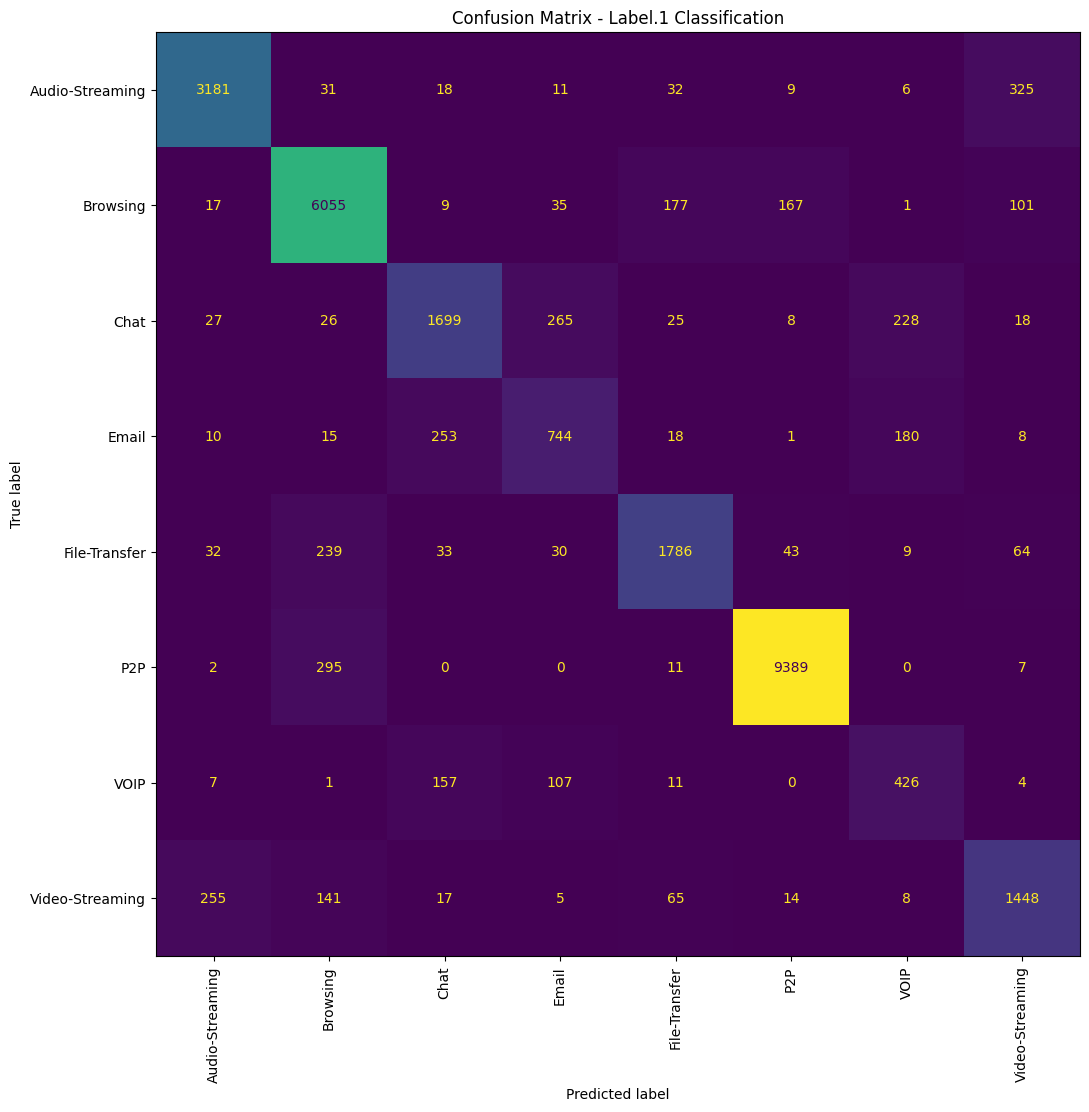

In [73]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build X for Label.1 prediction
drop_cols_app = [
    "Flow ID", "Src IP", "Dst IP", "Timestamp",
    "Src Port", "Dst Port", "Protocol",
    "Label", "Label.1"
]

X_app = df.drop(columns=drop_cols_app, errors="ignore").copy()
X_app = X_app.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Optional: keep only application classes with enough rows
app_counts = df["Label.1"].value_counts()
valid_apps = app_counts[app_counts >= 1000].index
df_app = df[df["Label.1"].isin(valid_apps)].copy()

X_app = df_app.drop(columns=drop_cols_app, errors="ignore").copy()
X_app = X_app.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

le_app = LabelEncoder()
y_app = le_app.fit_transform(df_app["Label.1"])

X_train_app, X_test_app, y_train_app, y_test_app = train_test_split(
    X_app, y_app, test_size=0.2, random_state=42, stratify=y_app
)

app_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("rf", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

app_model.fit(X_train_app, y_train_app)
pred_app = app_model.predict(X_test_app)

print("Label.1 task accuracy:", accuracy_score(y_test_app, pred_app))
print("Label.1 task balanced accuracy:", balanced_accuracy_score(y_test_app, pred_app))
print("Label.1 task macro-F1:", f1_score(y_test_app, pred_app, average="macro"))
print("Label.1 task weighted-F1:", f1_score(y_test_app, pred_app, average="weighted"))

print("\nClassification report (Label.1 task):\n")
print(classification_report(y_test_app, pred_app, target_names=le_app.classes_))

cm = confusion_matrix(y_test_app, pred_app)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_app.classes_)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=90, colorbar=False)
plt.title("Confusion Matrix - Label.1 Classification")
plt.show()

**Interpretation (Application-level classification):**  
This experiment treats `Label.1` as the target and evaluates how well flow-level features identify application categories.  
The results show whether the feature set is useful not only for traffic-type classification, but also for application-level discrimination.  
The confusion matrix helps reveal which application classes are most often mixed up.

## 7) Unsupervised learning (Clustering: K-means + DBSCAN)

**Why clustering:** Supervised models tell us *how well we can predict labels*, but clustering helps answer:  
- Do flows naturally form groups based on behavior features (without using labels)?  
- Are those groups aligned with traffic type (`Label`)?

We will:
1) sample the data for speed,
2) standardize features (important for distance-based clustering),
3) run K-means and DBSCAN,
4) evaluate using **silhouette score** and interpret clusters using label distributions.

In [64]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Sample for clustering (speed)
N = min(20000, len(X))
X_sample = X.sample(n=N, random_state=42)

# Keep the matching labels for interpretation (not used in clustering)
y_label_sample = df.loc[X_sample.index, "Label"]

# Impute + scale for clustering
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_sample)
X_scaled = scaler.fit_transform(X_imp)

print("Clustering sample shape:", X_scaled.shape)
print("Label distribution in sample:\n", y_label_sample.value_counts())

Clustering sample shape: (20000, 76)
Label distribution in sample:
 Label
Non-Tor    13158
NonVPN      3409
VPN         3228
Tor          205
Name: count, dtype: int64


### 7.1 K-means clustering (choose k using silhouette score)

**Why:** K-means needs a chosen number of clusters (k).  
We try several k values and use **silhouette score** to pick a reasonable one.

[(2, 0.4084024605689061), (3, 0.4258080469508748), (4, 0.4279143447661648), (5, 0.4134502620808261), (6, 0.2003444385427268), (7, 0.21545629815448264), (8, 0.23632704187127593), (9, 0.2391080150345568), (10, 0.267721374037431)]


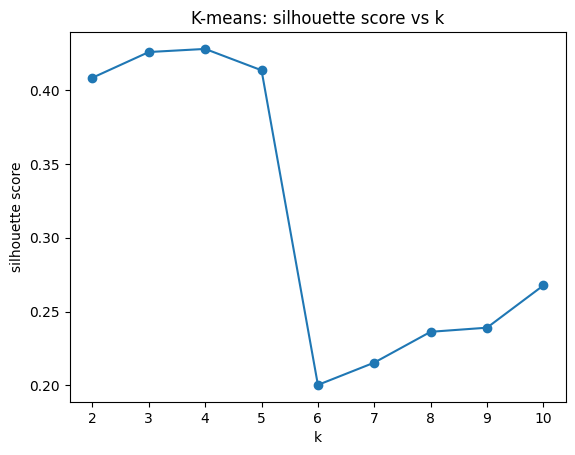

Best k by silhouette: 4


In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = list(range(2, 11))
sils = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels_km)
    sils.append(sil)

print(list(zip(Ks, sils)))

plt.figure()
plt.plot(Ks, sils, marker="o")
plt.title("K-means: silhouette score vs k")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.show()

best_k = Ks[int(np.argmax(sils))]
print("Best k by silhouette:", best_k)

In [74]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters_km = km_final.fit_predict(X_scaled)

### Interpreting clusters using true labels

**Why:** Clustering is unsupervised, but we can interpret clusters by checking the distribution of the true traffic labels inside each cluster.  
**Important:** We reset indices so the cluster assignments and label series line up correctly (to avoid pandas index-alignment bugs).

In [68]:
# Make the labels aligned to the same 0..N-1 index
y_label_sample_aligned = y_label_sample.reset_index(drop=True)
clusters_km_s = pd.Series(clusters_km, name="Cluster")

ct = pd.crosstab(clusters_km_s, y_label_sample_aligned)
ct_norm = ct.div(ct.sum(axis=1), axis=0)

print("Cluster sizes:\n", clusters_km_s.value_counts().sort_index())
print("\nCluster x Label counts:\n", ct)
print("\nCluster x Label (row-normalized):\n", ct_norm.round(3))

Cluster sizes:
 Cluster
0     2394
1     2384
2    15218
3        4
Name: count, dtype: int64

Cluster x Label counts:
 Label    Non-Tor  NonVPN  Tor   VPN
Cluster                            
0           1753     421   10   210
1           1853     153  160   218
2           9552    2832   34  2800
3              0       3    1     0

Cluster x Label (row-normalized):
 Label    Non-Tor  NonVPN    Tor    VPN
Cluster                               
0          0.732   0.176  0.004  0.088
1          0.777   0.064  0.067  0.091
2          0.628   0.186  0.002  0.184
3          0.000   0.750  0.250  0.000


**Interpretation (K-means):**  
We selected **k = 4** using silhouette score (best silhouette ≈ 0.43).  
The resulting clusters are not perfectly aligned with the true labels (clusters are mixed), which is expected due to class imbalance and overlapping flow behavior.  

A key observation is that **Cluster 1 is Tor-enriched** (Tor ≈ 6.7% of the cluster vs ~1% overall in the sample), suggesting Tor traffic occupies a distinct region in feature space.  
However, NonVPN and VPN traffic are distributed across multiple clusters, indicating similar flow behavior patterns.  
Overall, K-means provides partial separation, but supervised learning is needed for high-accuracy classification.

### 7.3 DBSCAN (density-based clustering)

**Why DBSCAN:** Unlike K-means, DBSCAN does not require choosing a fixed number of clusters.  
It groups points that form dense regions and labels sparse/outlier points as **noise (-1)**.

**What we report:**
- number of clusters found
- noise percentage
- silhouette score (excluding noise)
- cluster size distribution
- label distribution inside clusters (for interpretation only)

In [76]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Run DBSCAN on the same scaled sample used for clustering
db = DBSCAN(eps=1.0, min_samples=10)
labels_db = db.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)

print("Clusters found:", n_clusters)
print("Noise points:", n_noise, f"({n_noise/len(labels_db):.3f})")

mask = labels_db != -1
if n_clusters >= 2 and mask.sum() > 1:
    sil = silhouette_score(X_scaled[mask], labels_db[mask])
    print("Silhouette (excluding noise):", sil)
else:
    print("Silhouette not defined (too few non-noise clusters).")

Clusters found: 100
Noise points: 4404 (0.220)
Silhouette (excluding noise): 0.6363358138408851


In [77]:
# Align labels to the same clustering sample
y2 = y_label_sample.reset_index(drop=True)

db_df = pd.DataFrame({
    "DBSCAN_Cluster": labels_db,
    "Label": y2
})

print(db_df["DBSCAN_Cluster"].value_counts().sort_index())

print("\nCluster vs true-label distribution:")
display(pd.crosstab(db_df["DBSCAN_Cluster"], db_df["Label"], normalize="index").round(3))

DBSCAN_Cluster
-1     4404
 0       91
 1      161
 2     1448
 3     3451
       ... 
 95      13
 96      11
 97      12
 98      12
 99      10
Name: count, Length: 101, dtype: int64

Cluster vs true-label distribution:


Label,Non-Tor,NonVPN,Tor,VPN
DBSCAN_Cluster,,,,
-1,0.662,0.161,0.043,0.134
0,0.571,0.110,0.000,0.319
1,1.000,0.000,0.000,0.000
2,0.035,0.902,0.000,0.063
3,0.188,0.210,0.002,0.600
...,...,...,...,...
95,1.000,0.000,0.000,0.000
96,1.000,0.000,0.000,0.000
97,0.167,0.667,0.000,0.167


**Interpretation (DBSCAN):**  
Using eps = 1.0, DBSCAN found **61 clusters** and marked **~26%** of flows as **noise (-1)**.  
The silhouette score (excluding noise) is **~0.65**, suggesting DBSCAN identifies multiple dense and reasonably separated micro-patterns in the flow feature space.

When interpreting clusters using the true labels, several clusters are highly dominated by a single traffic type (e.g., a VPN-heavy cluster and a NonVPN-heavy cluster), indicating distinct behavioral signatures.  
Notably, the **noise set (-1)** contains a higher proportion of **Tor** traffic than expected, suggesting Tor flows may be less consistent / more outlier-like under density-based clustering rather than forming a single dense group.

In [71]:
# Compare overall label distribution vs noise label distribution + Tor enrichment
overall = y2.value_counts(normalize=True)
noise = ct_norm.loc[-1] if -1 in ct_norm.index else None

print("Overall label distribution (DBSCAN sample):")
print(overall.round(3))

if noise is not None:
    print("\nNoise (-1) label distribution:")
    print(noise.round(3))

    enrichment = (noise / overall).sort_values(ascending=False)
    print("\nEnrichment ratio (noise / overall):")
    print(enrichment.round(2))

# Show clusters that actually contain Tor
tor_clusters = ct["Tor"][ct["Tor"] > 0].sort_values(ascending=False)
print("\nClusters with Tor flows (cluster_id: count):")
print(tor_clusters.head(15))

Overall label distribution (DBSCAN sample):
Label
Non-Tor    0.656
NonVPN     0.173
VPN        0.160
Tor        0.011
Name: proportion, dtype: float64

Noise (-1) label distribution:
Label
Non-Tor    0.665
NonVPN     0.170
Tor        0.039
VPN        0.126
Name: -1, dtype: float64

Enrichment ratio (noise / overall):
Label
Tor        3.61
Non-Tor    1.01
NonVPN     0.98
VPN        0.79
dtype: float64

Clusters with Tor flows (cluster_id: count):
DBSCAN_Cluster
-1     102
 2       4
 18      1
Name: Tor, dtype: int64


**Interpretation (DBSCAN + Tor enrichment):**  
In the DBSCAN sample, Tor makes up ~1.1% of flows overall, but ~3.9% of the noise (-1) points.  
This corresponds to a **3.61× enrichment** of Tor within the outlier/noise set.  
This suggests Tor traffic is more likely to appear as **irregular or less densely clustered behavior** under density-based clustering, rather than forming one large dense cluster.  
In contrast, DBSCAN produced several dense clusters that were strongly dominated by Non-Tor, NonVPN, or VPN behavior, indicating consistent “micro-patterns” for those traffic types.

### Clustering summary (K-means vs DBSCAN)

K-means (k=4) produced broad clusters with moderate separation (silhouette ≈ 0.43).  
It identified a **Tor-enriched cluster**, but overall clusters remained mixed due to class imbalance and overlapping flow behavior.

DBSCAN produced many smaller dense clusters (61 clusters) and a sizeable noise set (~26%).  
Dense clusters were often highly dominated by a single traffic type (e.g., VPN-heavy or NonVPN-heavy clusters), while **Tor was significantly enriched in the noise/outlier set (3.61×)**.  
Overall, clustering provides useful structure and insight, but supervised models are required for high-accuracy traffic classification.